In [209]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### **Load the dataset**

In [210]:
df =pd.read_csv("../dataset/heart.csv")

### **Dataset Overview**

In [211]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [212]:
df.shape

(918, 12)

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [214]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [215]:
df.describe(include="object")

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [216]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [217]:
df.duplicated().sum()

np.int64(0)

#### Observations

- The dataset contains **918 rows** and **12 columns**.
- It includes both **numerical** and **categorical** features.
- No missing values or duplicate records were found in the dataset.
- Some numerical features may contain potential outliers, which will be investigated during the univariate analysis.
- - The target column indicates whether a patient has heart disease (1) or does not have heart disease (0).

### Identify Column Types

**Categorical Features**

In [218]:
cat_col = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "FastingBS"
]

**Numerical Features**

In [219]:
num_col = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "HeartDisease" 
]

### Univaraite Analysis

**Categorical features**

**Sex**

In [220]:
gender = pd.DataFrame({
    "Count": df["Sex"].value_counts(),
    "Percentage": df["Sex"].value_counts(normalize=True) * 100
})

gender

,Count,Percentage
Sex,,
M,725,78.976035
F,193,21.023965


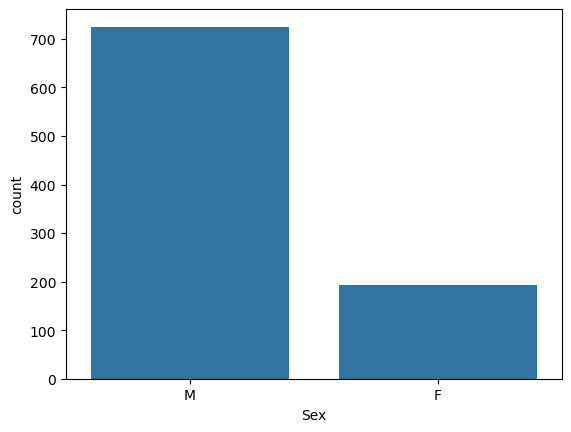

In [221]:
sns.countplot(x=df["Sex"]);

**ChestPainType**

In [222]:
chestPain = pd.DataFrame({
    "Count": df["ChestPainType"].value_counts(),
    "Percentage": df["ChestPainType"].value_counts(normalize=True) * 100
})

chestPain

,Count,Percentage
ChestPainType,,
ASY,496,54.030501
NAP,203,22.113290
ATA,173,18.845316
TA,46,5.010893


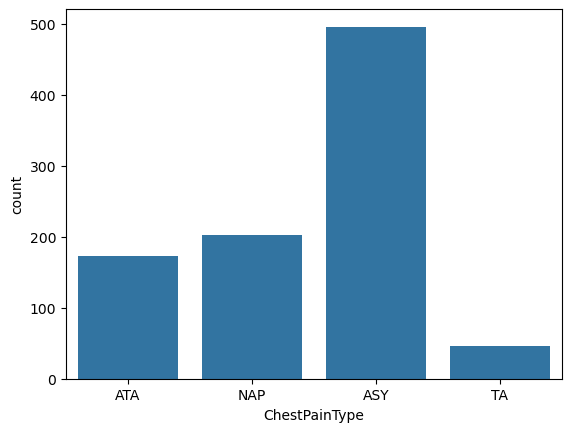

In [223]:
sns.countplot(x="ChestPainType", data=df);

**RestingECG**

In [224]:
ECG = pd.DataFrame({
    "Count": df["RestingECG"].value_counts(),
    "Percentage": df["RestingECG"].value_counts(normalize=True) * 100
})

ECG

,Count,Percentage
RestingECG,,
Normal,552,60.130719
LVH,188,20.479303
ST,178,19.389978


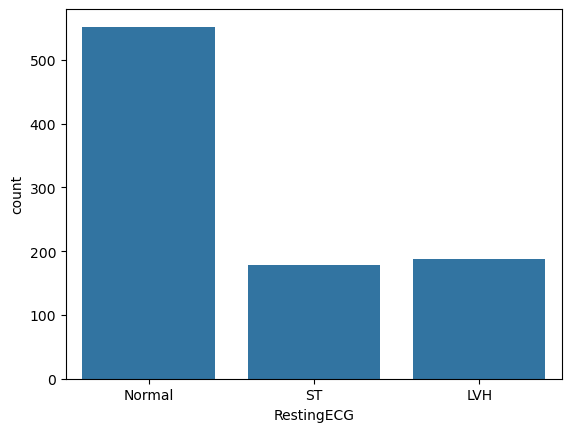

In [225]:
sns.countplot(x="RestingECG", data=df);

**ExerciseAngina**

In [226]:
Angina = pd.DataFrame({
    "Count": df["ExerciseAngina"].value_counts(),
    "Percentage": df["ExerciseAngina"].value_counts(normalize=True) * 100
})

Angina

,Count,Percentage
ExerciseAngina,,
N,547,59.586057
Y,371,40.413943


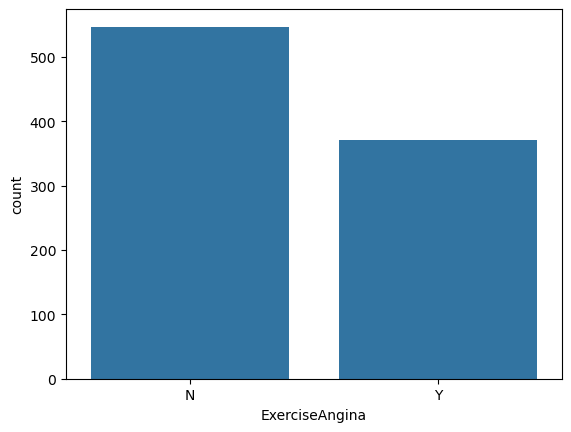

In [227]:
sns.countplot(x="ExerciseAngina", data=df);

In [228]:
st_slope_summary = pd.DataFrame({
    "Count": df["ST_Slope"].value_counts(),
    "Percentage": df["ST_Slope"].value_counts(normalize=True) * 100
})

st_slope_summary

,Count,Percentage
ST_Slope,,
Flat,460,50.108932
Up,395,43.028322
Down,63,6.862745


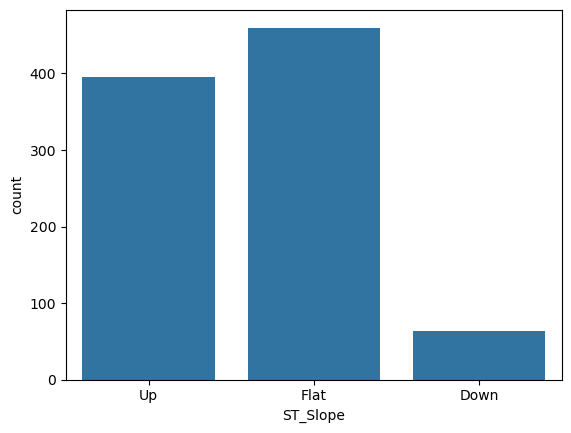

In [229]:
sns.countplot(x="ST_Slope", data=df);

**FastingBS**

In [230]:
FastingBSsummary = pd.DataFrame({
    "Count": df["FastingBS"].value_counts(),
    "Percentage": df["FastingBS"].value_counts(normalize=True) * 100
})

FastingBSsummary

,Count,Percentage
FastingBS,,
0,704,76.688453
1,214,23.311547


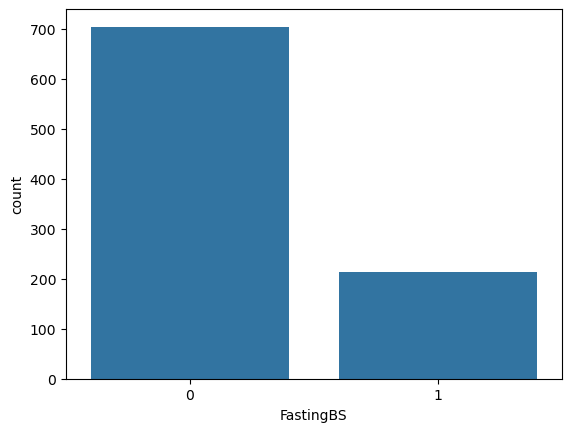

In [231]:
sns.countplot(x ='FastingBS',data=df);

* **Sex** contains 2 categories. **Male** is the dominant category, while **Female** is the least represented. The feature shows an imbalanced distribution.

* **ChestPainType** contains 4 categories. **ASY** is the most common category, whereas **TA** is the least common. The feature shows an imbalanced distribution.

* **RestingECG** contains 3 categories. **Normal** is the most common category, while **ST** is the least common. The feature shows an imbalanced distribution.

* **ExerciseAngina** contains 2 categories. **N** is the most common category, whereas **Y** is the least common. The feature shows an imbalanced distribution.

* **ST_Slope** contains 3 categories. **Flat** is the most common category, while **Down** is the least common. The feature shows an imbalanced distribution.
* **FastingBS** contains 2 categories. **0** is the most common category, while **1** is the least common. The feature shows an imbalanced distribution.



**Numerical Features**

**Age**

In [232]:
df["Age"].describe()

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

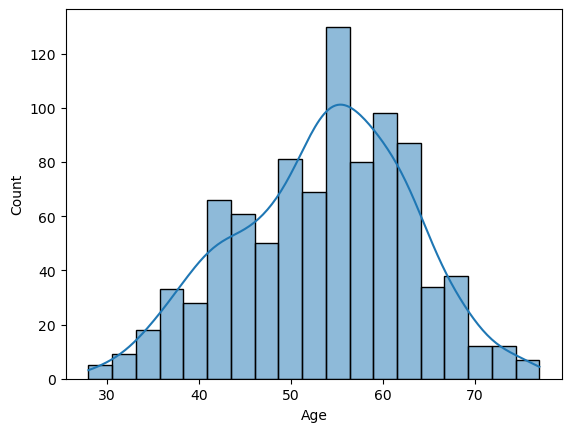

In [233]:
sns.histplot(x="Age",data=df,kde=True);

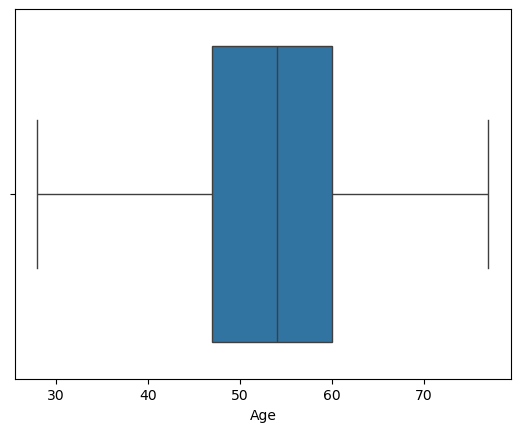

In [234]:
sns.boxplot(x="Age", data=df);

**Observation**

- The age distribution is slightly left-skewed.
- Most patients are between 27 and 60 years old.
- A few elderly patients appear in the dataset.
- No extreme outliers are observed.

**RestingBP**

In [235]:
df['RestingBP'].describe()

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

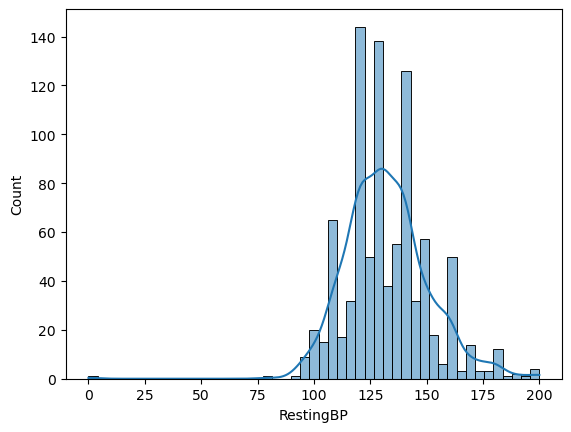

In [237]:
sns.histplot(x='RestingBP', data=df,kde=True);

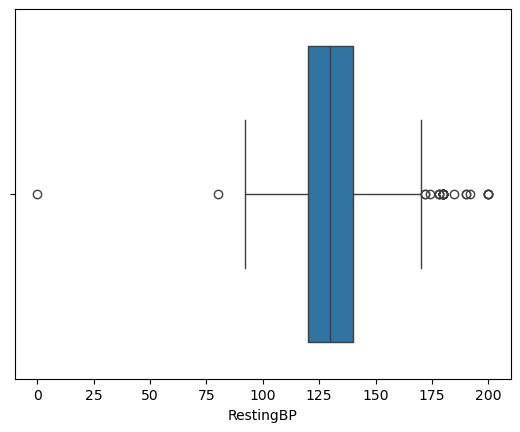

In [238]:
sns.boxplot(x=df['RestingBP']);

**Observation**

- The distribution of **RestingBP** is slightly right-skewed.
- The minimum value is **0**, which is not physiologically possible for a living person. This likely indicates an invalid or erroneous entry that should be addressed during the data cleaning stage.
- The boxplot suggests the presence of potential outliers, which will be investigated further during data cleaning.

In [239]:
df['Cholesterol'].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

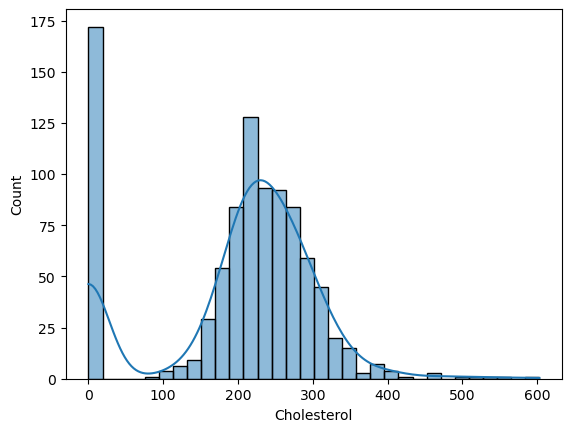

In [241]:
sns.histplot(x=df['Cholesterol'], kde=True);

<Axes: xlabel='Cholesterol'>

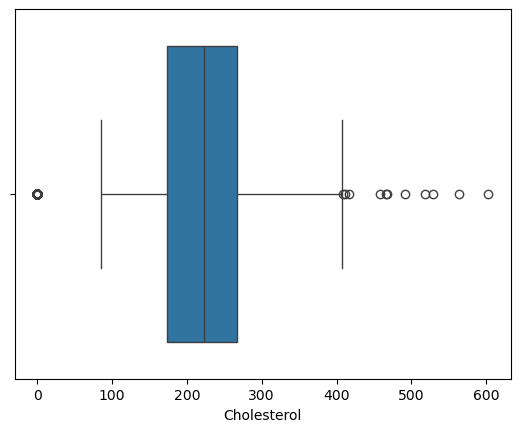

In [250]:
sns.boxplot(x="Cholesterol", data=df)

**Observation**

- The distribution of **Cholesterol** is slightly left-skewed.
- The minimum cholesterol value is **0**, which is not physiologically plausible for a living person. This likely indicates an invalid or erroneous entry and should be investigated during the data cleaning stage.
- The boxplot suggests the presence of potential outliers, which will be examined further during data cleaning.

**MaxHR**

In [242]:
df['MaxHR'].describe()

count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: MaxHR, dtype: float64

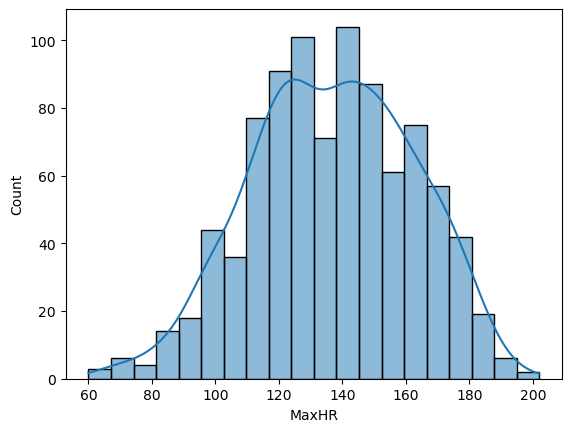

In [243]:
sns.histplot(x='MaxHR', data=df, kde=True);

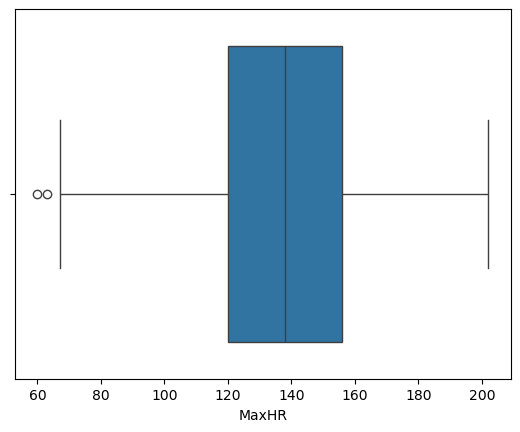

In [244]:
sns.boxplot(x='MaxHR', data=df);

**Oldpeak**

In [245]:
df['Oldpeak'].describe()

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

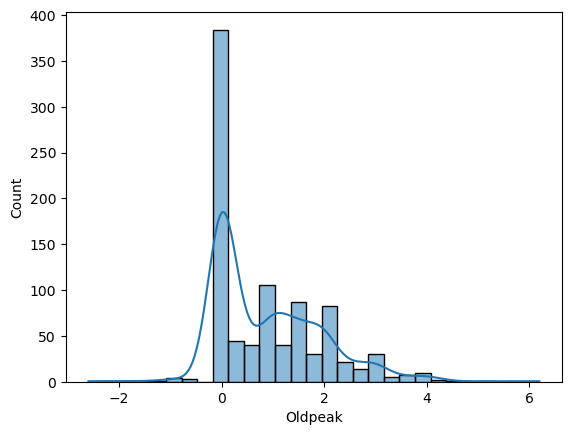

In [246]:
sns.histplot(x='Oldpeak', data=df, kde=True);

<Axes: xlabel='Oldpeak'>

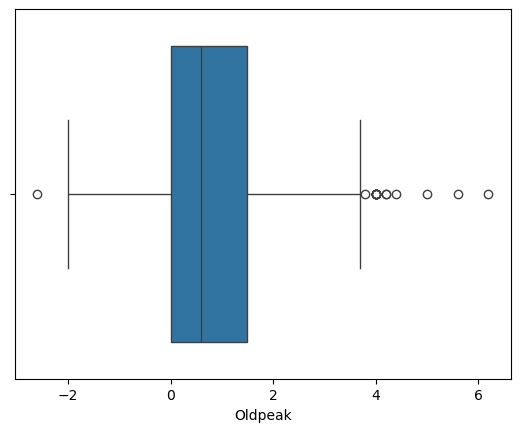

In [247]:
sns.boxplot(x='Oldpeak', data=df)

**Target column**

In [253]:
HeartDisease_summary = pd.DataFrame({
    "Count": df["HeartDisease"].value_counts(),
    "Percentage": df["HeartDisease"].value_counts(normalize=True) * 100
})
HeartDisease_summary

,Count,Percentage
HeartDisease,,
1,508,55.337691
0,410,44.662309


<Axes: xlabel='HeartDisease', ylabel='count'>

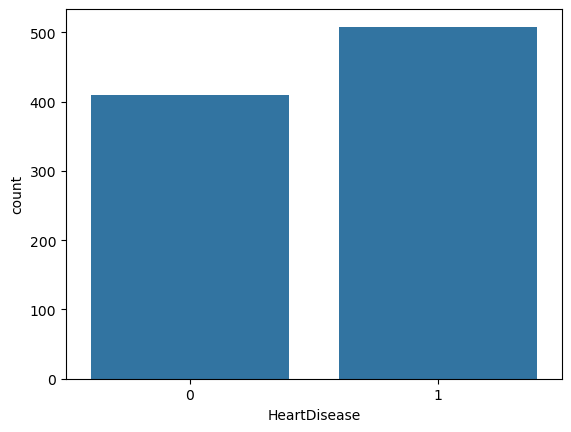

In [249]:
sns.countplot(x='HeartDisease', data=df)